## Extension Analysis Work (on-going)

In [2]:
from tabulate import tabulate
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

pd.set_option('display.max_rows', None)  
pd.set_option('display.max_columns', None)  
pd.set_option('display.expand_frame_repr', False)

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [3]:
def joules_to_kwh(joules):
    return float(joules) / 3600000

def load_philipp_data(cluster, workflow, runs):
    processed = {}

    for run in range(1, runs+1):
        with open(f'nxf-experiments/{cluster}-cluster/{workflow}/{run}/wf_data.csv') as file:
            stripped_lines = [line.rstrip().split(',') for line in file.readlines()]
            data = stripped_lines[1:]

        pkg = data[0][11]
        dram = data[0][12]
        total = data[0][13]

        processed[run] = {}
        processed[run]['pkg'] = joules_to_kwh(pkg)
        processed[run]['dram'] = joules_to_kwh(dram)
        processed[run]['total'] = joules_to_kwh(total)
    
    return processed


def load_data_totals(cluster, workflow, runs):
    processed = {}

    for run in range(1, runs+1):
        proc_data = pd.read_csv(f'nxf-experiments/{cluster}-cluster/{workflow}/{run}/trace.csv', header=0)
        processed[run] = {}
        processed[run]['read'] = proc_data['read_bytes'].sum() / 1073741824  # convert from B to GiB
        processed[run]['write'] = proc_data['write_bytes'].sum() / 1073741824  # convert from B to GiB

    return processed


def load_philipp_total_energy(cluster, workflow, runs):
    processed = {}
        
    for run in range(1, runs+1):
        with open(f'nxf-experiments/{cluster}-cluster/{workflow}/{run}/task_data.md') as file:
            lines = [line.strip() for line in file.readlines()]

        final = lines[-1].split(': ')[1][:-6]

        processed[run] = {}
        processed[run]['pkg'] = None
        processed[run]['dram'] = None
        processed[run]['total'] = joules_to_kwh(final)
    
    return processed

In [4]:
# Functions to parse rapl data
def load_workflow_rapl_readings(cluster, workflow):
    with open(f'nxf-experiments/{cluster}-cluster/{workflow}-runs.csv', 'r') as file:
        data = [line.strip().split(',') for line in file.readlines()]
    
    return data[1:]

gu_socket = {'rnaseq': 'both', 'chipseq': 'both', 'nanoseq': 'both', 'atacseq': 'both'}

def process_rapl_data(data, gu=False, wf=''):
    processed = {}
    run = 1

    for row in data:
        if gu:
            active_pkg_1 = float(row[7])
            active_pkg_2 = float(row[16])
            active_dram_1 = float(row[8])
            active_dram_2 = float(row[17])
            rapl_pkg = active_pkg_1 + active_pkg_2
            rapl_mem = active_dram_1 + active_dram_2
            rapl_total = rapl_pkg + rapl_mem
        else:
            active_pkg = float(row[7])
            rapl_pkg = active_pkg
            active_dram = float(row[8])
            rapl_mem = active_dram
            rapl_total = rapl_pkg + rapl_mem

        processed[run] = {}
        processed[run]['pkg'] = rapl_pkg
        processed[run]['dram'] = rapl_mem
        processed[run]['total'] = rapl_total
        run += 1

    return processed

In [5]:
# Functions to parse ichnos data
def load_ichnos_summary_file(summary_file):
    with open(summary_file, 'r') as file:
        raw = [line.strip() for line in file.readlines()]

    cpu = float(raw[8].split(':')[1].strip()[:-3])
    task_mem = float(raw[10].split(':')[1].strip()[:-3])
    node_mem = float(raw[16].split(':')[1].strip()[:-3])
    cpu_static = float(raw[7].split(':')[1].strip()[:-3])

    return (cpu, task_mem, node_mem, cpu_static)

def load_ichnos_data(cluster, workflow, runs, strategy, ci):
    workflow_path = f'nxf-experiments/{cluster}-cluster/{workflow}/ichnos'
    data = {}

    for run in range(1, runs + 1):
        data[run] = {}
        (cpu, task_mem, node_mem, cpu_stat) = load_ichnos_summary_file(f'{workflow_path}/{cluster}-{workflow}-{run}-{ci}-{strategy}-summary.txt')
        data[run]['pkg'] = cpu
        data[run]['mem_dyn'] = task_mem
        data[run]['mem_stat'] = node_mem 
        data[run]['total'] = cpu + task_mem
        data[run]['pkg_stat'] = cpu_stat

    return data

In [6]:
# Generic functions
def get_error(experimental, actual):
    return round((abs(experimental - actual) / actual) * 100, 2)

def get_error_dir(experimental, actual):
    return round(((experimental - actual) / actual) * 100, 2)

In [7]:
def load_nxf_trace(cluster, workflow, run, print=False):
    filepath = f'nxf-experiments/{cluster}-cluster/{workflow}/{run}/trace.csv'
    nxf_trace = pd.read_csv(filepath, header=0)
    start_ms = min(nxf_trace['start'])
    end_ms = max(nxf_trace['complete'])
    runtime = (end_ms - start_ms) / 1000 / 60  # mins
    start_day = datetime.fromtimestamp(start_ms / 1000).strftime('%Y-%m-%d')
    end_day = datetime.fromtimestamp(end_ms / 1000).strftime('%Y-%m-%d')
    nxf_trace['memory'] /= 1073741824

    if print:
        print(f'{cluster} {workflow} {run} took {runtime:.0f}m on {start_day} to {end_day}')

    return (nxf_trace, runtime)

In [8]:
def plot_task_length_fig(vals, workflow):
    plt.figure(figsize=(6,2))
    plt.violinplot(vals['realtime'] / 1000 / 60, vert=False, showmedians=True, showextrema=True)
    plt.title(workflow)
    plt.xlabel('time (m)')
    plt.xlim(0,60)
    plt.show()

In [9]:
def explore_workflow(wf, wf_df, time, node_mem, run):
    avg_task_cpu_usage = np.median(wf_df['%cpu'])
    avg_task_runtime = np.median(wf_df['realtime'] / 1000)

    print(f'[{wf}]')
    print(f'no. tasks {len(wf_df)}, runtime {time:.0f}m, task {avg_task_runtime:.0f}s, cpu% {avg_task_cpu_usage:.1f}%')
    print(f'cpu [i: {run['ichnos_pkg']}, r: {run['rapl_pkg']}, e: {run['err_pkg']}]')
    print(f'mem [i: {run['ichnos_task_mem']}, r: {run['rapl_mem']}, e: {run['err_mem']}]')

In [10]:
def report_memory_utilisation(wf_df, node_mem, cluster, workflow, run):
    interval = 5 * 1000  # 5s intervals
    tasks_by_node = wf_df.groupby('hostname')
    utilisation_split = {}

    for node, group_df in tasks_by_node:
        node_id = node.split('-')[-1].strip()
        node_active_periods_file = f'nxf-experiments/{cluster}-cluster/{workflow}/{run}/energy/active_{node_id}.csv'
        periods_df = pd.read_csv(node_active_periods_file)
        earliest = group_df['start'].min()
        latest = group_df['complete'].max()
        bins = np.arange(earliest, latest + interval, interval)
        bin_ends = bins + interval

        in_active_period = np.any(
            (bins[:, np.newaxis] < periods_df['end_ms'].values[np.newaxis, :]) &
            (bin_ends[:, np.newaxis] > periods_df['start_ms'].values[np.newaxis, :]),
            axis=1
        )
        filtered_bins = bins[in_active_period]
        filtered_bin_ends = bin_ends[in_active_period]

        if len(filtered_bins) == 0:
            print(f"Warning: no bins fall within active periods for node {node}, skipping.")
            continue

        active = (
            (group_df['start'].values[np.newaxis, :] < filtered_bin_ends[:, np.newaxis]) &
            (group_df['complete'].values[np.newaxis, :] > filtered_bins[:, np.newaxis])
        )

        memory = group_df['memory'].values
        usage_over_time = np.round(active @ memory / node_mem) * 100

        total = len(usage_over_time)
        vals, counts = np.unique(usage_over_time, return_counts=True)

        low_mask = vals < 10
        node_low_bins = int(counts[low_mask].sum())
        node_high_bins = int(counts[~low_mask].sum())

        utilisation_split[node] = {
            'low_pct':  round(node_low_bins / total * 100, 1),
            'high_pct': round(node_high_bins / total * 100, 1),
            'low_secs':  node_low_bins * 5,
            'high_secs': node_high_bins * 5,
        }

    return utilisation_split

In [11]:
def analyse_workflow(wf, wf_df, time, node_mem, node_cpus, wf_run):
    explore_workflow(wf, wf_df, time, node_mem, wf_run)
    plot_task_length_fig(wf_df, wf)

In [12]:
mem_coefficients_by_node = {
    'hu-worker-c40': (0.023, 0.055),
    'hu-worker-c42': (0.030, 0.060),
    'hu-worker-c44': (0.026, 0.058),
    'hu-worker-c45': (0.032, 0.062),
    'gpgnode-15': (0.231, 0.255),
    # temporary values for other gpg nodes
    'gpgnode-13': (0.231, 0.255),
    'gpgnode-14': (0.231, 0.255),
    'gpgnode-16': (0.231, 0.255),
    'gpgnode-17': (0.231, 0.255),
    'gpgnode-18': (0.231, 0.255)
}

In [13]:
# load all workflow rapl and ichnos data
rapl_data = {'hu': {}, 'gu': {}}
rapl_data['hu']['rnaseq'] = process_rapl_data(load_workflow_rapl_readings('hu', 'rnaseq'), False, 'rnaseq')
rapl_data['hu']['chipseq'] = process_rapl_data(load_workflow_rapl_readings('hu', 'chipseq'), False, 'chipseq')
rapl_data['hu']['atacseq'] = process_rapl_data(load_workflow_rapl_readings('hu', 'atacseq'), False, 'atacseq')
rapl_data['hu']['rangeland'] = process_rapl_data(load_workflow_rapl_readings('hu', 'rangeland'), False, 'rangeland')
rapl_data['hu']['nanoseq'] = process_rapl_data(load_workflow_rapl_readings('hu', 'nanoseq'), False, 'nanoseq')
rapl_data['hu']['sarek'] = process_rapl_data(load_workflow_rapl_readings('hu', 'sarek'), False, 'sarek')

rapl_data['gu']['atacseq'] = process_rapl_data(load_workflow_rapl_readings('gu', 'atacseq'), True, 'atacseq')
rapl_data['gu']['chipseq'] = process_rapl_data(load_workflow_rapl_readings('gu', 'chipseq'), True, 'chipseq')
rapl_data['gu']['nanoseq'] = process_rapl_data(load_workflow_rapl_readings('gu', 'nanoseq'), True, 'nanoseq')
rapl_data['gu']['rnaseq'] = process_rapl_data(load_workflow_rapl_readings('gu', 'rnaseq'), True, 'rnaseq')

ichnos_data = {'hu': {}, 'gu': {}}
ichnos_data['hu']['rnaseq'] = load_ichnos_data('hu', 'rnaseq', len(rapl_data['hu']['rnaseq']), 'schedutil_linear', 'de-2025-11-17-2025-11-24')
ichnos_data['hu']['chipseq'] = load_ichnos_data('hu', 'chipseq', len(rapl_data['hu']['chipseq']), 'schedutil_linear', 'de-2025-11-17-2025-11-24')
ichnos_data['hu']['atacseq'] = load_ichnos_data('hu', 'atacseq', len(rapl_data['hu']['atacseq']), 'performance_linear', 'de-2026-02-20-2026-02-24')
ichnos_data['hu']['rangeland'] = load_ichnos_data('hu', 'rangeland', len(rapl_data['hu']['rangeland']), 'schedutil_linear', 'de-2025-11-17-2025-11-24')
ichnos_data['hu']['nanoseq'] = load_ichnos_data('hu', 'nanoseq', len(rapl_data['hu']['nanoseq']), 'performance_linear', 'de-2026-03-05-2026-03-07')
ichnos_data['hu']['sarek'] = load_ichnos_data('hu', 'sarek', len(rapl_data['hu']['sarek']), 'schedutil_linear', 'de-2026-02-07-2026-02-09')

ichnos_data['gu']['rnaseq'] = load_ichnos_data('gu', 'rnaseq', len(rapl_data['gu']['rnaseq']), 'ondemand_linear', 'gb-2026-01-28-2026-01-30')
ichnos_data['gu']['atacseq'] = load_ichnos_data('gu', 'atacseq', len(rapl_data['gu']['atacseq']), 'ondemand_linear', 'gb-2026-02-27-2026-02-28')
ichnos_data['gu']['chipseq'] = load_ichnos_data('gu', 'chipseq', len(rapl_data['gu']['chipseq']), 'ondemand_linear', 'gb-2026-01-28-2026-01-30')
ichnos_data['gu']['nanoseq'] = load_ichnos_data('gu', 'nanoseq', len(rapl_data['gu']['nanoseq']), 'ondemand_linear', 'gb-2026-02-10-2026-02-12')

io_data = {'hu': {}, 'gu': {}}
io_data['hu']['rnaseq'] = load_data_totals('hu', 'rnaseq', 3)
io_data['hu']['chipseq'] = load_data_totals('hu', 'chipseq', 3)
io_data['hu']['atacseq'] = load_data_totals('hu', 'atacseq', 3)
io_data['hu']['rangeland'] = load_data_totals('hu', 'rangeland', 3)
io_data['hu']['nanoseq'] = load_data_totals('hu', 'nanoseq', 3)
io_data['hu']['sarek'] = load_data_totals('hu', 'sarek', 3)

io_data['gu']['rnaseq'] = load_data_totals('gu', 'rnaseq', 3)
io_data['gu']['chipseq'] = load_data_totals('gu', 'chipseq', 3)
io_data['gu']['atacseq'] = load_data_totals('gu', 'atacseq', 3)
io_data['gu']['nanoseq'] = load_data_totals('gu', 'nanoseq', 3)

table_data = []
table_head = ['cluster', 'workflow', 'run', 
              'ichnos_pkg', 'rapl_pkg', 'err_pkg', 
              'ichnos_task_mem', 'rapl_mem', 'err_mem', 
              'ichnos_total', 'rapl_total', 'err_total', 
              'ichnos_static_mem', 'static_err_mem', 'ichnos_static_cpu']

for cluster, node_mem in zip(['hu', 'gu'], [256, 64]):
    for workflow in rapl_data[cluster].keys():
        for run in range(1, len(rapl_data[cluster][workflow].keys()) + 1):
            rapl_entry = rapl_data[cluster][workflow][run]
            rapl_pkg = rapl_entry['pkg']
            rapl_dram = rapl_entry['dram']
            ichnos_entry = ichnos_data[cluster][workflow][run]
            ichnos_pkg = ichnos_entry['pkg']
            ichnos_mem_dyn = ichnos_entry['mem_dyn']
            i_pkg_stat = ichnos_entry['pkg_stat']
            i_mem_stat = ichnos_entry['mem_stat']
            io_entry = io_data[cluster][workflow][run]

            table_data.append([cluster, workflow, run, 
                               round(ichnos_pkg, 2), round(rapl_pkg, 2), get_error(ichnos_pkg, rapl_pkg), 
                               round(ichnos_mem_dyn, 2), round(rapl_dram, 2), get_error(ichnos_mem_dyn, rapl_dram), 
                               round(ichnos_entry['total'], 2), round(rapl_entry['total'], 2), get_error(ichnos_entry['total'], rapl_entry['total']), 
                               round(i_mem_stat, 2), get_error(i_mem_stat, rapl_dram), round(i_pkg_stat, 2)])

all_data = pd.DataFrame(table_data, columns=table_head)

In [14]:
# isolate median workflow runs (gu)
gu_nanoseq, gu_nanoseq_time = load_nxf_trace('gu', 'nanoseq', 1)
gu_atacseq, gu_atacseq_time = load_nxf_trace('gu', 'atacseq', 3)
gu_rnaseq, gu_rnaseq_time = load_nxf_trace('gu', 'rnaseq', 1)
gu_chipseq, gu_chipseq_time = load_nxf_trace('gu', 'chipseq', 3)

In [15]:
# isolate median workflow runs (hu)
hu_nanoseq, hu_nanoseq_time = load_nxf_trace('hu', 'nanoseq', 2)
hu_atacseq, hu_atacseq_time = load_nxf_trace('hu', 'atacseq', 2)
hu_rangeland, hu_rangeland_time = load_nxf_trace('hu', 'rangeland', 2)
hu_rnaseq, hu_rnaseq_time = load_nxf_trace('hu', 'rnaseq', 2)
hu_chipseq, hu_chipseq_time = load_nxf_trace('hu', 'chipseq', 1)
hu_sarek, hu_sarek_time = load_nxf_trace('hu', 'sarek', 3)

In [15]:
rows_hu = all_data[all_data['cluster'] == 'hu'].reset_index()
median_rows_hu = rows_hu.sort_values(['workflow', 'rapl_total']).groupby('workflow').nth(1)
run_nanoseq_hu = median_rows_hu[median_rows_hu['workflow'] == 'nanoseq'].iloc[0]
run_atacseq_hu = median_rows_hu[median_rows_hu['workflow'] == 'atacseq'].iloc[0]
run_rangeland_hu = median_rows_hu[median_rows_hu['workflow'] == 'rangeland'].iloc[0]
run_rnaseq_hu = median_rows_hu[median_rows_hu['workflow'] == 'rnaseq'].iloc[0]
run_chipseq_hu = median_rows_hu[median_rows_hu['workflow'] == 'chipseq'].iloc[0]
run_sarek_hu = median_rows_hu[median_rows_hu['workflow'] == 'sarek'].iloc[0]
all_cpu_pred_errors = []
all_task_mem_pred_errors = []
all_cpu_task_mem_pred_errors = []
all_node_pred_mem_errors = []
all_cpu_node_pred_errors = []

for _, row in median_rows_hu.iterrows():
    print(f"{row['cluster']} & {row['workflow']} & {row['ichnos_pkg']} & {row['rapl_pkg']} & {row['err_pkg']} & {row['ichnos_task_mem']} & {row['rapl_mem']} & {row['err_mem']} & {row['ichnos_total']} & {row['rapl_total']} & {row['err_total']} \\\\")

hu & atacseq & 0.47 & 0.47 & 0.15 & 0.03 & 0.06 & 52.44 & 0.5 & 0.53 & 5.9 \\
hu & chipseq & 3.53 & 4.12 & 14.41 & 0.3 & 0.54 & 44.06 & 3.83 & 4.66 & 17.85 \\
hu & nanoseq & 0.34 & 0.34 & 1.98 & 0.02 & 0.06 & 71.25 & 0.35 & 0.4 & 11.59 \\
hu & rangeland & 1.56 & 2.0 & 22.29 & 0.17 & 0.25 & 30.48 & 1.73 & 2.25 & 23.2 \\
hu & rnaseq & 1.71 & 1.99 & 14.11 & 0.15 & 0.24 & 38.98 & 1.86 & 2.23 & 16.83 \\
hu & sarek & 3.83 & 4.4 & 12.85 & 0.16 & 0.62 & 74.82 & 3.99 & 5.01 & 20.47 \\


In [16]:
rows_gu = all_data[all_data['cluster'] == 'gu'].reset_index()
median_rows_gu = rows_gu.sort_values(['workflow', 'rapl_total']).groupby('workflow').nth(1)
run_nanoseq_gu = median_rows_gu[median_rows_gu['workflow'] == 'nanoseq'].iloc[0]
run_atacseq_gu = median_rows_gu[median_rows_gu['workflow'] == 'atacseq'].iloc[0]
run_rnaseq_gu = median_rows_gu[median_rows_gu['workflow'] == 'rnaseq'].iloc[0]
run_chipseq_gu = median_rows_gu[median_rows_gu['workflow'] == 'chipseq'].iloc[0]

for _, row in median_rows_gu.iterrows():
    print(f"{row['cluster']} & {row['workflow']} & {row['ichnos_pkg']} & {row['rapl_pkg']} & {row['err_pkg']} & {row['ichnos_task_mem']} & {row['rapl_mem']} & {row['err_mem']} & {row['ichnos_total']} & {row['rapl_total']} & {row['err_total']} \\\\")

gu & atacseq & 0.91 & 0.9 & 1.4 & 0.14 & 0.17 & 16.89 & 1.06 & 1.08 & 1.55 \\
gu & chipseq & 1.29 & 1.31 & 1.69 & 0.21 & 0.23 & 8.99 & 1.5 & 1.54 & 2.78 \\
gu & nanoseq & 0.58 & 0.58 & 0.91 & 0.09 & 0.12 & 29.78 & 0.67 & 0.7 & 4.53 \\
gu & rnaseq & 0.99 & 0.96 & 3.06 & 0.15 & 0.18 & 15.38 & 1.15 & 1.15 & 0.12 \\


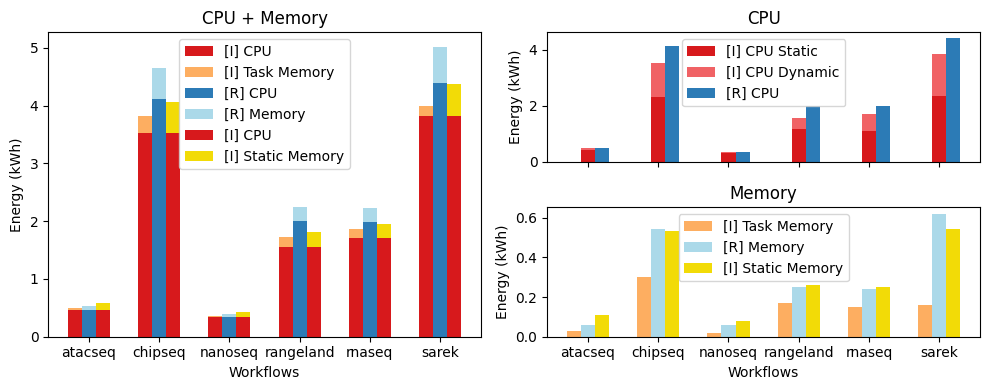

In [17]:
# Ichnos (energy visualisation)
layout = [['L', 'T'], ['L', 'B']]
fig, axs = plt.subplot_mosaic(layout, figsize=(10, 4), sharex=True)

wfs = median_rows_hu.index
x = np.arange(6)
width = 0.2

# cpu + memory
axs['L'].set_title('CPU + Memory')
axs['L'].bar(x - width, median_rows_hu['ichnos_pkg'].values, width, label='[I] CPU', color='#d7191c')
axs['L'].bar(x - width, median_rows_hu['ichnos_task_mem'].values, width, bottom=median_rows_hu['ichnos_pkg'].values, label='[I] Task Memory', color='#fdae61')
axs['L'].bar(x, median_rows_hu['rapl_pkg'].values, width, label='[R] CPU', color='#2c7bb6')
axs['L'].bar(x, median_rows_hu['rapl_mem'].values, width, bottom=median_rows_hu['rapl_pkg'].values, label='[R] Memory', color='#abd9e9')
axs['L'].bar(x + width, median_rows_hu['ichnos_pkg'].values, width, label='[I] CPU', color='#d7191c')
axs['L'].bar(x + width, median_rows_hu['ichnos_static_mem'].values, width, bottom=median_rows_hu['ichnos_pkg'].values, label='[I] Static Memory', color='#f2db07')
axs['L'].set_xticks(x, labels=median_rows_hu['workflow'].values)
axs['L'].set_ylabel('Energy (kWh)')
axs['L'].legend(loc='upper center')

# cpu
axs['T'].set_title('CPU')
axs['T'].bar(x, median_rows_hu['ichnos_static_cpu'].values, width, label='[I] CPU Static', color='#d7191c')
axs['T'].bar(x, median_rows_hu['ichnos_pkg'].values - median_rows_hu['ichnos_static_cpu'].values, width, bottom=median_rows_hu['ichnos_static_cpu'].values, label='[I] CPU Dynamic', color='#f06265')
axs['T'].bar(x + width, median_rows_hu['rapl_pkg'].values, width, label='[R] CPU', color='#2c7bb6')
axs['T'].set_ylabel('Energy (kWh)')
axs['T'].set_xticks(x, labels=median_rows_hu['workflow'].values)
axs['T'].legend(loc='upper center')

# memory
axs['B'].set_title('Memory')
axs['B'].bar(x - width, median_rows_hu['ichnos_task_mem'].values, width, label='[I] Task Memory', color='#fdae61')
axs['B'].bar(x, median_rows_hu['rapl_mem'].values, width, label='[R] Memory', color='#abd9e9')
axs['B'].bar(x + width, median_rows_hu['ichnos_static_mem'].values, width, label='[I] Static Memory', color='#f2db07')
axs['B'].set_ylabel('Energy (kWh)')
axs['B'].set_xticks(x, labels=median_rows_hu['workflow'].values)
axs['B'].legend(loc='upper center')

axs['B'].set_xlabel('Workflows')
axs['L'].set_xlabel('Workflows')

plt.tight_layout()

def save_subplot(fig, ax, path, padding=1.1):
    renderer = fig.canvas.get_renderer()
    bbox_display = ax.get_tightbbox(renderer)
    bbox_inches = bbox_display.transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(path, bbox_inches=bbox_inches.expanded(padding, padding))

save_subplot(fig, axs['L'], "images/ichnos-vs-rapl-total.pdf")
save_subplot(fig, axs['T'], "images/ichnos-vs-rapl-cpu.pdf")
save_subplot(fig, axs['B'], "images/ichnos-vs-rapl-memory.pdf")
plt.savefig('images/ichnos-vs-rapl.pdf')
plt.show()

[nanoseq]
no. tasks 92, runtime 90m, task 24s, cpu% 123.5%
cpu [i: 0.34, r: 0.34, e: 1.98]
mem [i: 0.02, r: 0.06, e: 71.25]


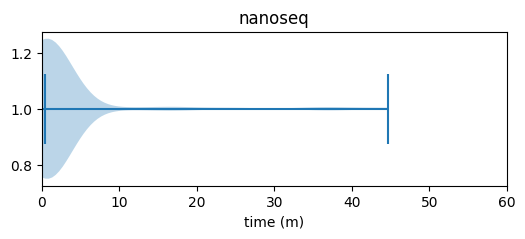

In [18]:
analyse_workflow('nanoseq', hu_nanoseq, hu_nanoseq_time, 256, 32, run_nanoseq_hu)

[atacseq]
no. tasks 268, runtime 110m, task 29s, cpu% 127.2%
cpu [i: 0.47, r: 0.47, e: 0.15]
mem [i: 0.03, r: 0.06, e: 52.44]


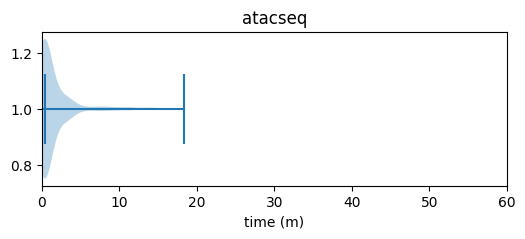

In [19]:
analyse_workflow('atacseq', hu_atacseq, hu_atacseq_time, 256, 32, run_atacseq_hu)

[rangeland]
no. tasks 3154, runtime 255m, task 22s, cpu% 100.5%
cpu [i: 1.56, r: 2.0, e: 22.29]
mem [i: 0.17, r: 0.25, e: 30.48]


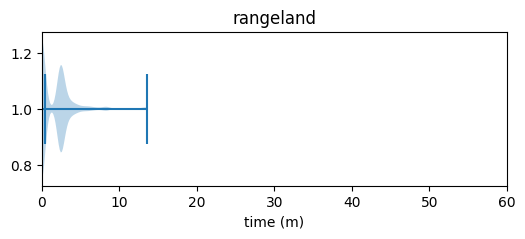

In [20]:
analyse_workflow('rangeland', hu_rangeland, hu_rangeland_time, 256, 32, run_rangeland_hu)

[rnaseq]
no. tasks 1269, runtime 251m, task 71s, cpu% 111.3%
cpu [i: 1.71, r: 1.99, e: 14.11]
mem [i: 0.15, r: 0.24, e: 38.98]


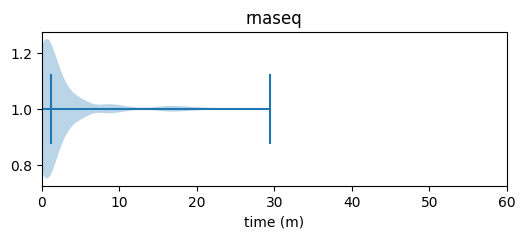

In [21]:
analyse_workflow('rnaseq', hu_rnaseq, hu_rnaseq_time, 256, 32, run_rnaseq_hu)

[chipseq]
no. tasks 3538, runtime 605m, task 31s, cpu% 128.4%
cpu [i: 3.53, r: 4.12, e: 14.41]
mem [i: 0.3, r: 0.54, e: 44.06]


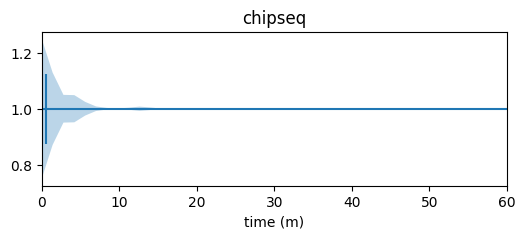

In [22]:
analyse_workflow('chipseq', hu_chipseq, hu_chipseq_time, 256, 32, run_chipseq_hu)

[sarek]
no. tasks 7430, runtime 518m, task 56s, cpu% 144.4%
cpu [i: 3.83, r: 4.4, e: 12.85]
mem [i: 0.16, r: 0.62, e: 74.82]


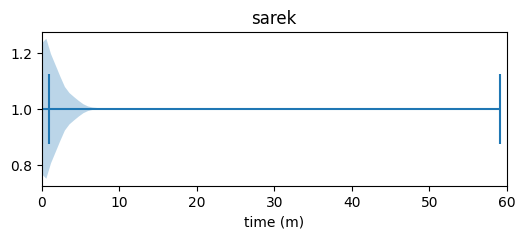

In [23]:
analyse_workflow('sarek', hu_sarek, hu_sarek_time, 256, 32, run_sarek_hu)

[nanoseq]
no. tasks 92, runtime 217m, task 67s, cpu% 100.0%
cpu [i: 0.58, r: 0.58, e: 0.91]
mem [i: 0.09, r: 0.12, e: 29.78]


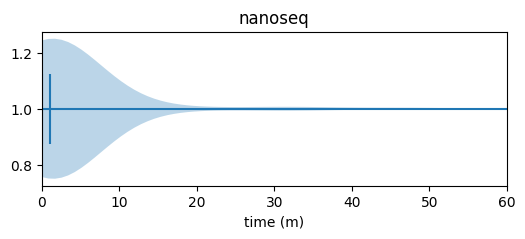

In [24]:
analyse_workflow('nanoseq', gu_nanoseq, gu_nanoseq_time, 64, 32, run_nanoseq_gu)

[atacseq]
no. tasks 268, runtime 251m, task 57s, cpu% 120.0%
cpu [i: 0.91, r: 0.9, e: 1.4]
mem [i: 0.14, r: 0.17, e: 16.89]


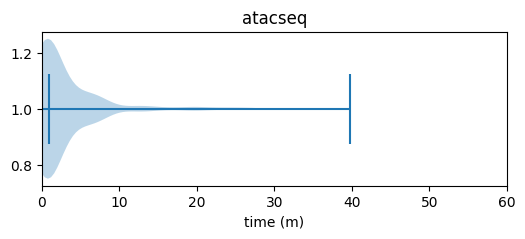

In [25]:
analyse_workflow('atacseq', gu_atacseq, gu_atacseq_time, 64, 32, run_atacseq_gu)

[rnaseq]
no. tasks 231, runtime 253m, task 125s, cpu% 108.1%
cpu [i: 0.99, r: 0.96, e: 3.06]
mem [i: 0.15, r: 0.18, e: 15.38]


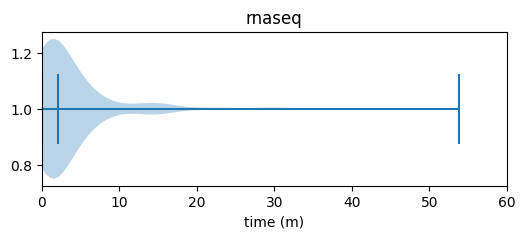

In [26]:
analyse_workflow('rnaseq', gu_rnaseq, gu_rnaseq_time, 64, 32, run_rnaseq_gu)

[chipseq]
no. tasks 314, runtime 311m, task 80s, cpu% 121.0%
cpu [i: 1.29, r: 1.31, e: 1.69]
mem [i: 0.21, r: 0.23, e: 8.99]


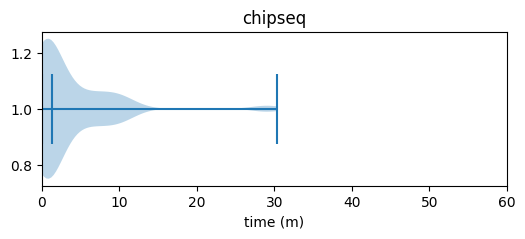

In [27]:
analyse_workflow('chipseq', gu_chipseq, gu_chipseq_time, 64, 32, run_chipseq_gu)

In [28]:
# todo -- take functions from eval.ipynb
# print the graphs (only the governors we are interested in), for the workflow runs with the:
# - 4x GPG nodes
# - 4x HU nodes

In [29]:
def load_nfco2fp_summary(cluster, workflow, run):
    filepath = f'nf-co2footprint/output/{cluster}-cluster/co2fp-summary-{workflow}-{run}.txt'
    with open(filepath, 'r') as file:
        data = file.readlines()

    energy_val, energy_unit = data[2].split(':')[1].strip().split(' ')
    if energy_unit == 'Wh':
        return float(energy_val) / 1000
    elif energy_unit == 'kWh':
        return float(energy_val)

In [30]:
print('hu-cluster')
hu_copy = rows_hu.copy()
heads = ['wf', 'run', 'ichnos', 'rapl', 'nfco2', 'dyn_only', 'stat_only', 'ichnos_statmem']
hu_data = []
hu_idle_cpu = 51.2  # W
hu_idle_mem = 7.3  # W

for _, row in hu_copy.iterrows():
    wf = row['workflow']
    run = row['run']
    i_total = row['ichnos_total']
    i_total_statmem = round(row['ichnos_pkg'] + row['ichnos_static_mem'], 2)
    r_total = row['rapl_total']
    nfco2_dynamic = load_nfco2fp_summary('hu', wf, run)

    # calculate static_energy for the nf-co2footprint plugin
    nxf_trace, _ = load_nxf_trace('hu', wf, run, print=False)
    tasks_by_node = nxf_trace.groupby('hostname')
    idle_energy = 0.0
    for node, group_df in tasks_by_node:
        node_id = node.split('-')[-1].strip()
        node_active_periods_file = f'nxf-experiments/hu-cluster/{wf}/{run}/energy/active_{node_id}.csv'
        periods_df = pd.read_csv(node_active_periods_file)
        node_active_time = np.sum(periods_df['duration_ms']) / 1000 / 60 / 60
        node_energy = node_active_time * (hu_idle_cpu + hu_idle_mem) * 0.001  # convert to kWh
        idle_energy += node_energy

    nfco2_total = round(nfco2_dynamic + idle_energy, 2)
    hu_data.append([wf, run, i_total, r_total, nfco2_total, round(nfco2_dynamic, 2), round(idle_energy, 2), i_total_statmem])

print(tabulate(hu_data, headers=heads))

hu-cluster
wf           run    ichnos    rapl    nfco2    dyn_only    stat_only    ichnos_statmem
---------  -----  --------  ------  -------  ----------  -----------  ----------------
rnaseq         1      1.85    2.22     2.05        1.12         0.93              1.95
rnaseq         2      1.86    2.23     2.05        1.11         0.94              1.96
rnaseq         3      1.87    2.25     2.06        1.11         0.95              1.98
chipseq        1      3.83    4.66     4.23        2.28         1.95              4.06
chipseq        2      3.82    4.66     4.22        2.28         1.94              4.04
chipseq        3      3.81    4.65     4.21        2.27         1.94              4.04
atacseq        1      0.49    0.51     0.4         0.15         0.25              0.57
atacseq        2      0.5     0.53     0.4         0.14         0.26              0.58
atacseq        3      0.51    0.54     0.41        0.14         0.27              0.59
rangeland      1      1.73    2.

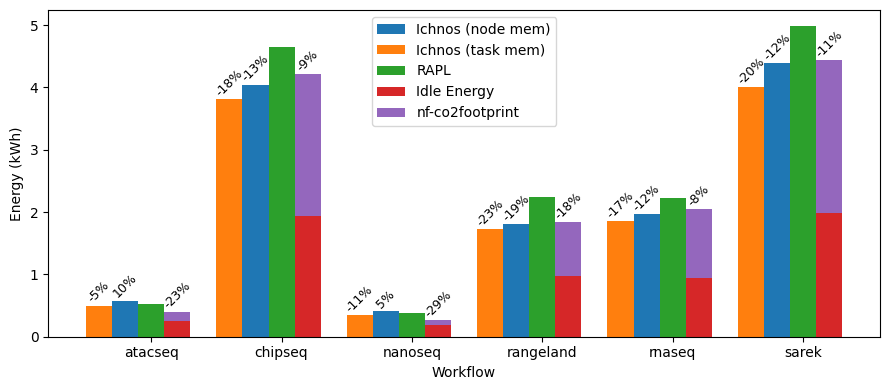

In [40]:
hu_baseline_comp = pd.DataFrame(hu_data, columns=heads)
hu_baseline_grouped = hu_baseline_comp.groupby('wf').mean()

wfs = hu_baseline_grouped.index
x = np.arange(6)
width = 0.2
fig, ax = plt.subplots(figsize=(9, 4))

bars = {
    'ichnos_statmem': ax.bar(x - (width * 1), hu_baseline_grouped['ichnos_statmem'].values, width, label='Ichnos (node mem)'),
    'ichnos':         ax.bar(x - (width * 2),        hu_baseline_grouped['ichnos'].values,         width, label='Ichnos (task mem)'),
    'rapl':           ax.bar(x,                 hu_baseline_grouped['rapl'].values,            width, label='RAPL'),
}

stat_vals = hu_baseline_grouped['stat_only'].values
dyn_vals  = hu_baseline_grouped['dyn_only'].values
bars['stat_only'] = ax.bar(x + width, stat_vals,  width, label='Idle Energy')
bars['dyn_only']  = ax.bar(x + width, dyn_vals,   width, bottom=stat_vals, label='nf-co2footprint')

rapl = hu_baseline_grouped['rapl'].values

def annotate_bars(bar_container, values, offsets=None):
    for i, (bar, val) in enumerate(zip(bar_container, values)):
        error = get_error_dir(val, rapl[i])
        bar_top = bar.get_height() + (offsets[i] if offsets is not None else 0)
        ax.text(bar.get_x() + bar.get_width() / 2, bar_top, f'{error:.0f}%', ha='center', va='bottom', rotation=45, fontsize=9)

annotate_bars(bars['ichnos_statmem'], hu_baseline_grouped['ichnos_statmem'].values)
annotate_bars(bars['ichnos'],         hu_baseline_grouped['ichnos'].values)
annotate_bars(bars['dyn_only'], stat_vals + dyn_vals, offsets=stat_vals)

ax.set_ylabel('Energy (kWh)')
ax.set_xticks(x, wfs)
ax.set_xlabel('Workflow')
ax.legend()

plt.tight_layout()
plt.savefig('images/ichnos-vs-nfco2-hu.pdf')
plt.show()

In [32]:
print('gu-cluster')
gu_copy = rows_gu.copy()
heads = ['wf', 'run', 'ichnos', 'rapl', 'nfco2', 'dyn_only', 'stat_only', 'ichnos_statmem']
gu_data = []
gu_idle_cpu = 1547.72 / 30.001519643
gu_idle_mem = 432.73 / 30.001519643

for _, row in gu_copy.iterrows():
    wf = row['workflow']
    run = row['run']
    i_total = row['ichnos_total']
    i_total_statmem = round(row['ichnos_pkg'] + row['ichnos_static_mem'], 2)
    r_total = row['rapl_total']
    nfco2_dynamic = load_nfco2fp_summary('gu', wf, run)

    # calculate static_energy for the nf-co2footprint plugin
    nxf_trace, _ = load_nxf_trace('hu', wf, run, print=False)
    tasks_by_node = nxf_trace.groupby('hostname')
    idle_energy = 0.0
    for node, group_df in tasks_by_node:
        node_id = node.split('-')[-1].strip()
        node_active_periods_file = f'nxf-experiments/hu-cluster/{wf}/{run}/energy/active_{node_id}.csv'
        periods_df = pd.read_csv(node_active_periods_file)
        node_active_time = np.sum(periods_df['duration_ms']) / 1000 / 60 / 60
        node_energy = node_active_time * (gu_idle_cpu + gu_idle_mem) * 0.001  # convert to kWh
        idle_energy += node_energy

    nfco2_total = round(nfco2_dynamic + idle_energy, 2)
    gu_data.append([wf, run, i_total, r_total, nfco2_total, round(nfco2_dynamic, 2), round(idle_energy, 2), i_total_statmem])

print(tabulate(gu_data, headers=heads))

gu-cluster
wf         run    ichnos    rapl    nfco2    dyn_only    stat_only    ichnos_statmem
-------  -----  --------  ------  -------  ----------  -----------  ----------------
atacseq      1      1.06    1.07     0.73        0.45         0.29              1.14
atacseq      2      1.05    1.09     0.74        0.45         0.29              1.13
atacseq      3      1.06    1.08     0.75        0.44         0.3               1.13
chipseq      1      1.51    1.53     2.88        0.68         2.2               1.62
chipseq      2      1.5     1.54     2.86        0.68         2.19              1.6
chipseq      3      1.52    1.54     2.87        0.68         2.19              1.63
nanoseq      1      0.67    0.7      0.47        0.28         0.19              0.72
nanoseq      2      0.64    0.68     0.49        0.28         0.22              0.7
nanoseq      3      0.66    0.7      0.5         0.28         0.22              0.71
rnaseq       1      1.12    1.16     1.48        0.43   

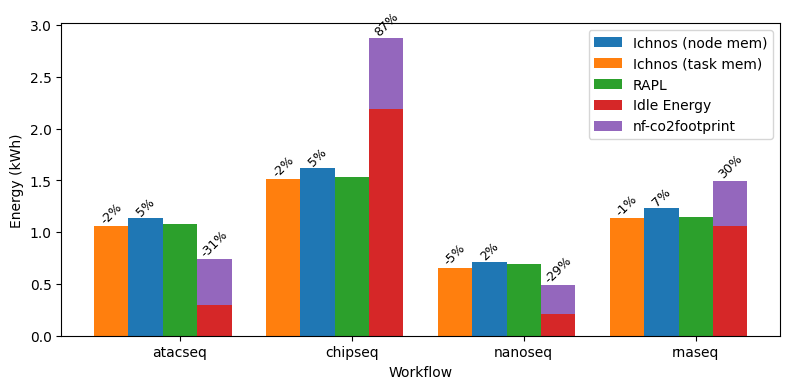

In [41]:
gu_baseline_comp = pd.DataFrame(gu_data, columns=heads)
gu_baseline_grouped = gu_baseline_comp.groupby('wf').mean()

wfs = gu_baseline_grouped.index
x = np.arange(4)
width = 0.20
fig, ax = plt.subplots(figsize=(8, 4))

bars = {
    'ichnos_statmem': ax.bar(x - (width * 1), gu_baseline_grouped['ichnos_statmem'].values, width, label='Ichnos (node mem)'),
    'ichnos':         ax.bar(x - (width * 2),        gu_baseline_grouped['ichnos'].values,         width, label='Ichnos (task mem)'),
    'rapl':           ax.bar(x,                 gu_baseline_grouped['rapl'].values,            width, label='RAPL'),
}

stat_vals = gu_baseline_grouped['stat_only'].values
dyn_vals  = gu_baseline_grouped['dyn_only'].values
bars['stat_only'] = ax.bar(x + width, stat_vals,  width, label='Idle Energy')
bars['dyn_only']  = ax.bar(x + width, dyn_vals,   width, bottom=stat_vals, label='nf-co2footprint')

rapl = gu_baseline_grouped['rapl'].values

def annotate_bars(bar_container, values, offsets=None):
    for i, (bar, val) in enumerate(zip(bar_container, values)):
        error = get_error_dir(val, rapl[i])
        bar_top = bar.get_height() + (offsets[i] if offsets is not None else 0)
        ax.text(bar.get_x() + bar.get_width() / 2, bar_top, f'{error:.0f}%', ha='center', va='bottom', rotation=45, fontsize=9)

annotate_bars(bars['ichnos_statmem'], gu_baseline_grouped['ichnos_statmem'].values)
annotate_bars(bars['ichnos'],         gu_baseline_grouped['ichnos'].values)
annotate_bars(bars['dyn_only'], stat_vals + dyn_vals, offsets=stat_vals)

ax.set_ylabel('Energy (kWh)')
ax.set_xticks(x, wfs)
ax.set_xlabel('Workflow')
ax.legend()

plt.tight_layout()
plt.savefig('images/ichnos-vs-nfco2-gu.pdf')
plt.show()